Example code for "Giant Second Harmonic Generation from Membrane Metasurfaces". The structure is a silver relief grating coupled to a SiO2 slab.

L. Qu et al., “Giant Second Harmonic Generation from Membrane Metasurfaces,” Nano Letters, vol. 22, no. 23, pp. 9652–9657, Nov. 2022, doi: https://doi.org/10.1021/acs.nanolett.2c03811.

The optical constants of LiNbO3 (Lithium niobate) are collected from:
https://refractiveindex.info/?shelf=main&book=LiNbO3&page=Zelmon-o

In [4]:
import pandas as pd
import numpy as np
from inkstone import Inkstone
from matplotlib import pyplot as plt
from helper_functions import *

# Function to setup the simulation
def setup_simulation(s, wavelength, structure='hole'):
    n_LiNbO3 = get_refractive_index('dataset/LiNbO3.csv', wavelength)
    s.AddMaterial(name='LiNbO3', epsilon=n_LiNbO3**2)

    s.AddLayer(name='in', thickness=0, material_background='vacuum')
    if structure == 'hole':
        s.AddLayer(name='hole', thickness=0.21, material_background='LiNbO3')
        s.AddPatternDisk(layer='hole', pattern_name='disk', material='vacuum', radius=0.1125)
    elif structure == 'cylinder':
        s.AddLayer(name='cylinder', thickness=0.68, material_background='vacuum')
        s.AddLayer(name='substrate', thickness=1.17, material_background='LiNbO3')
        s.AddPatternDisk(layer='cylinder', pattern_name='disk', material='LiNbO3', radius=0.1125)
    s.AddLayerCopy(name='out', original_layer='in', thickness=0)

# Function to calculate reflection for a single angle and set of wavelengths
def calculate_reflection(wavelengths, angle, structure='hole'):
    reflection = []
    for wavelength in wavelengths:
        s = Inkstone()
        s.lattice = ((0.6, 0), (0, 0.6))
        s.num_g = 30

        setup_simulation(s, wavelength, structure)

        s.SetExcitation(theta=angle, phi=0, s_amplitude=1, p_amplitude=0)
        s.SetFrequency(1 / wavelength)

        flux_in = s.GetPowerFlux('in')
        incident = flux_in[0]
        reflection_value = -flux_in[1] / incident
        reflection.append(reflection_value)

    return np.array(reflection)

# Function to calculate reflection spectrum over multiple angles
def calculate_reflection_spectrum(wavelengths, angles, structure='hole'):
    reflection_spectrum = np.zeros((len(wavelengths), len(angles)))

    for i, angle in enumerate(angles):
        reflection_spectrum[:, i] = calculate_reflection(wavelengths, angle, structure)

    return reflection_spectrum

# Plotting: Stacked reflection curves
def plot_reflection_curves_stacked(wavelengths, angles, reflection_curves, offset=1.0):
    plt.figure(figsize=(8, 10))
    for i, angle in enumerate(angles):
        plt.plot(wavelengths, reflection_curves[:, i] + i * offset, label=f'θ = {angle}°')
        plt.text(wavelengths[-1] + 0.01, i * offset, f'θ = {angle}°', verticalalignment='center')

    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Reflection (Offset)')
    plt.title('Stacked Reflection Curves Under Different Incident Angles')
    plt.xlim([wavelengths.min(), wavelengths.max()])
    plt.ylim([0, len(angles) * offset])
    plt.legend()
    plt.show()

# Plotting: Heatmap of reflection spectrum
def plot_heatmap(angles, wavelengths, reflection_spectrum):
    plt.figure(figsize=(10, 8))
    plt.imshow(reflection_spectrum, aspect='auto', extent=[angles[0], angles[-1], wavelengths[0], wavelengths[-1]],
               origin='lower', cmap='hot')
    plt.colorbar(label='Reflection')
    plt.xlabel('Angle of incidence (deg)')
    plt.ylabel('Wavelength (nm)')
    plt.title('Reflection spectrum as a function of angle and wavelength')
    plt.show()


In [ ]:
# Main script
wavelengths = np.linspace(0.8, 1.2, 41)  # Adjust the wavelength range as needed
angles = np.linspace(0, 10, 11)  # Specific angles to plot

# Dictionary to store reflection data for each angle
reflection_curves = []

# Perform the reflection calculation for each angle
for angle in angles:
    reflection_curve = calculate_reflection(wavelengths, angle)
    reflection_curves.append(reflection_curve)

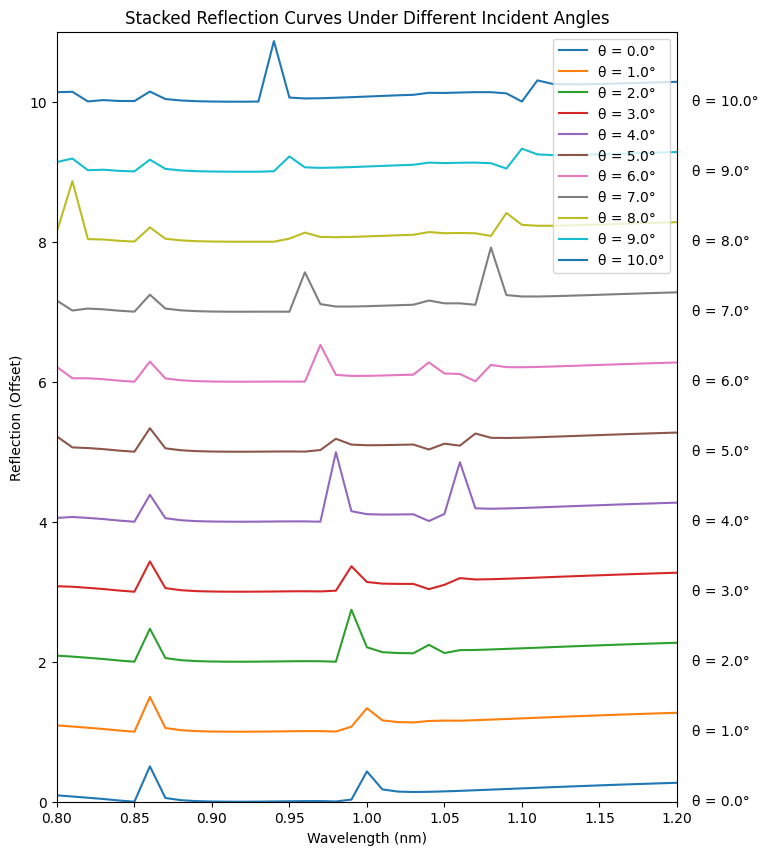

In [10]:
# Convert the list of reflection curves into a 2D NumPy array
reflection_curves = np.array(reflection_curves).T  # Transpose to match (wavelengths, angles) shape

# Plot the reflection curves
plot_reflection_curves_stacked(wavelengths, angles, reflection_curves, offset=1.0)

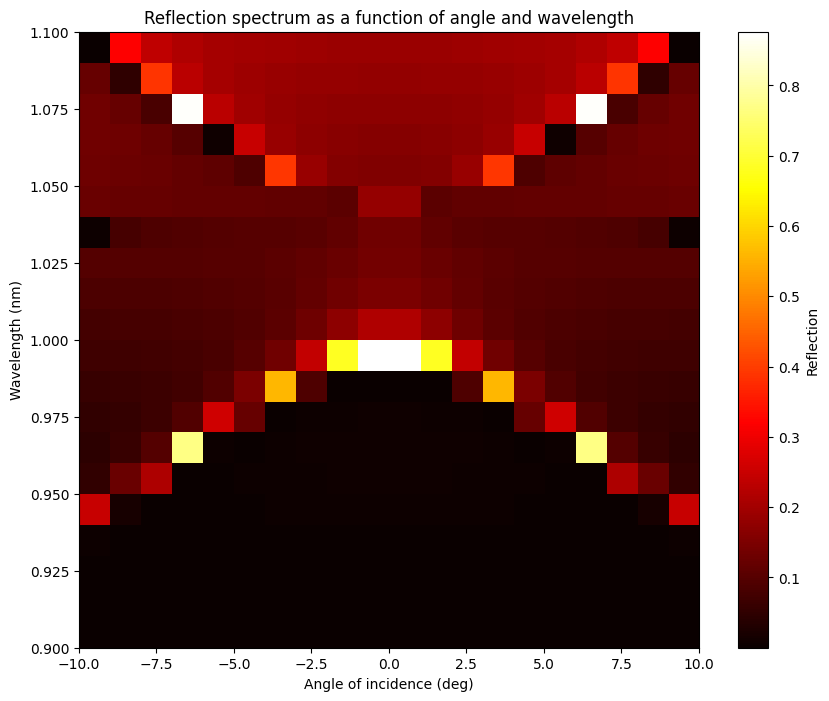

In [23]:
# Main script
wavelengths = np.linspace(0.9, 1.1, 20)  # Adjust the wavelength range as needed
angles = np.linspace(-10, 10, 20)  # Adjust the angle range as needed

# Calculate the reflection spectrum
reflection_spectrum = calculate_reflection_spectrum(wavelengths, angles)

# Plot the heatmap
plot_heatmap(angles, wavelengths, reflection_spectrum)